# SR3 RV Lab — Framework 6: curvature vs vol, and the vol surface's own shape

**RV class: A / C.**

Three related questions, all marked on listed prices:

* **6a Fly vs straddle** — the futures butterfly prices the *velocity* of the
  policy path; the belly straddle prices its *dispersion*. Both are claims on
  the same random path but neither pins the other, so their relative richness
  is a real basis. The package is the belly straddle against the `+1/-2/+1`
  futures fly, delta-hedged daily so the straddle's own direction is removed.
* **6b Vol butterfly** — `½(hike_iv + cut_iv) - atm_iv`, the smile's curvature
  in listed normal-vol terms, traded as a strangle against a vega-matched
  straddle. Bimodal policy pricing bids the wings; a diffuse path bids the ATM.
* **6c Skew term structure** — the risk reversal *in vol space* differenced
  across adjacent expiries: does hike/cut skew live in the near window or the
  far one, and does the spread revert or trend?

In [1]:
CONFIG = dict(
    wing_offset=0.25,
    strike_tol=0.13,
    min_oi=100,
    min_tte=0.15,
    contracts_per_leg=100,
    cost_bp=2.5,
    mas=(1, 5, 10),
    zscore_windows=(60, 120),
    entry_zs=(1.0, 1.5, 2.0),
    exits=("t5", "t10", "z0"),
    directions=("fade", "momentum"),
)
CONFIG

{'wing_offset': 0.25,
 'strike_tol': 0.13,
 'min_oi': 100,
 'min_tte': 0.15,
 'contracts_per_leg': 100,
 'cost_bp': 2.5,
 'mas': (1, 5, 10),
 'zscore_windows': (60, 120),
 'entry_zs': (1.0, 1.5, 2.0),
 'exits': ('t5', 't10', 'z0'),
 'directions': ('fade', 'momentum')}

In [2]:
import dataclasses
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sfr_rv_lab_common import LabConfig, load_lab, run_framework
from RVUtils.SFRRVLab import (
    Leg, Structure, add_event_distance, atm_premium_panel,
    constant_maturity_slots, contract_pairs, quarterly_sort_key, vol_smile_panel,
)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

lab = load_lab()
quotes, contracts = lab["quotes"], lab["contracts"]
tte = constant_maturity_slots(contracts)[["as_of", "symbol", "tte", "cm_slot"]]

atm = atm_premium_panel(quotes, contracts).merge(tte, on=["as_of", "symbol"])
atm = atm[atm["tte"] >= CONFIG["min_tte"]]
vs = vol_smile_panel(quotes, contracts, offset=CONFIG["wing_offset"],
                     tol=CONFIG["strike_tol"], min_oi=CONFIG["min_oi"])
vs = vs.merge(tte, on=["as_of", "symbol"])
vs = vs[vs["tte"] >= CONFIG["min_tte"]]
print(f"atm rows {len(atm)}   vol-smile rows {len(vs)}")
print(vs.groupby("symbol")[["atm_iv_bp", "rr_iv_bp", "fly_iv_bp"]].median()
      .round(2).to_string())

atm rows 1540   vol-smile rows 1470
        atm_iv_bp  rr_iv_bp  fly_iv_bp
symbol                                
SFRH27      89.72     -1.12       0.24
SFRH28     101.73      3.32       0.37
SFRM27      89.78     -0.67       0.47
SFRM28     101.50      2.64       0.02
SFRU27      86.40      0.15       0.50
SFRZ26      82.78     -1.67       0.06
SFRZ27      97.48      1.72       0.44


## 6a — fly vs straddle

`signal = z(fly_bp) - z(belly straddle premium)`: the futures fly rich against
the belly's option-implied dispersion. Sign convention is the desk one,
`fly = 2*belly - front - back` in bp (note `BT/signals/sfr_cal_spread_rv.
compute_fly_curve` uses the opposite sign).

In [3]:
SYMS = sorted(contracts["symbol"].unique(), key=quarterly_sort_key)
TRIPLES = [(SYMS[i], SYMS[i + 1], SYMS[i + 2]) for i in range(len(SYMS) - 2)]
fwd = contracts.set_index(["as_of", "symbol"])["forward_rate"]
atm_idx = atm.set_index(["as_of", "symbol"])

rows = []
for a, b, c in TRIPLES:
    dates = sorted(set(atm_idx.xs(b, level="symbol").index))
    for ts in dates:
        try:
            fa, fb, fc = (float(fwd[(ts, a)]), float(fwd[(ts, b)]),
                          float(fwd[(ts, c)]))
            st = atm_idx.loc[(ts, b)]
        except KeyError:
            continue
        rows.append({
            "as_of": ts, "key": f"{a}-{b}-{c}", "front": a, "belly": b, "back": c,
            "fly_bp": (2 * fb - fa - fc) * 100.0,
            "straddle_bp": float(st["atm_straddle_bp"]),
            "belly_strike": float(st["atm_strike"]),
        })
fly = pd.DataFrame(rows)
if not fly.empty:
    g = fly.groupby("key")
    fly["fly_z"] = g["fly_bp"].transform(
        lambda s: (s - s.rolling(120, min_periods=40).mean())
        / s.rolling(120, min_periods=40).std(ddof=0))
    fly["str_z"] = g["straddle_bp"].transform(
        lambda s: (s - s.rolling(120, min_periods=40).mean())
        / s.rolling(120, min_periods=40).std(ddof=0))
    fly["signal"] = fly["fly_z"] - fly["str_z"]
    fly["gate"] = True
    fly = add_event_distance(fly.dropna(subset=["signal"]))
print(f"fly-vs-straddle rows: {len(fly)}  triples: "
      f"{fly['key'].nunique() if len(fly) else 0}")

fly-vs-straddle rows: 592  triples: 4


  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 6a. Fly vs belly straddle — grid ===
  108 configs | median -40.26bp | IQR [-131.29, +70.21] | 44% net-positive | best +178.73bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum   5            120               1.5        t10        10     0.800      17.873       178.730      446825.00   2.411    -73.821
 momentum  10             60               2.0         z0         4     0.750      43.118       172.470      431175.50   4.322    -41.433
 momentum  10            120               2.0         z0         3     0.667      48.755       146.265      365662.25   4.211    -42.307
 momentum  10             60               1.5        t10        12     0.667      12.147       145.759      364396.75   1.576   -142.959
 momentum   5            120               1.0        t10        15     0.667       9.547       143.209   

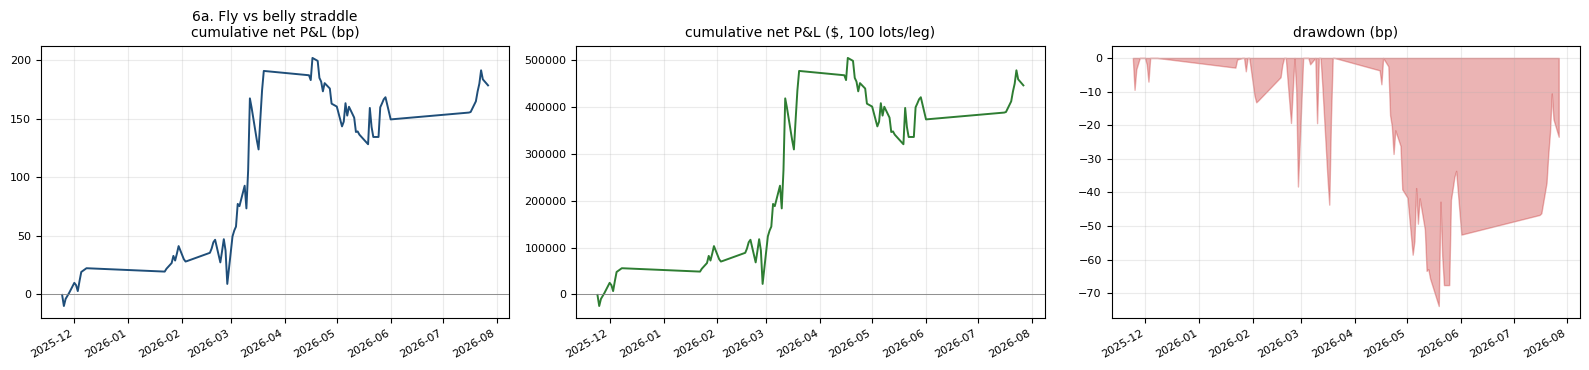


TRADE LOG (first rows)
                 key  dir                         structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp   net_bp   net_usd  stale_frac  pkg_contracts exit_reason
SFRZ26-SFRH27-SFRM27   -1 flyVstraddle SFRZ26-SFRH27-SFRM27  2025-11-20 2025-11-21 2025-12-08    10 -1.669   24.8422      2.5  22.3422  55855.57       0.186            6.0        time
SFRH27-SFRM27-SFRU27    1 flyVstraddle SFRH27-SFRM27-SFRU27  2026-01-20 2026-01-21 2026-02-04    10  1.572    8.6910      2.5   6.1910  15477.62       0.177            6.0        time
SFRZ26-SFRH27-SFRM27   -1 flyVstraddle SFRZ26-SFRH27-SFRM27  2026-02-12 2026-02-13 2026-03-02    10 -1.613   19.7386      2.5  17.2386  43096.42       0.191            6.0        time
SFRH27-SFRM27-SFRU27   -1 flyVstraddle SFRH27-SFRM27-SFRU27  2026-02-17 2026-02-18 2026-03-04    10 -1.598   14.6543      2.5  12.1543  30385.77       0.191            6.0        time
SFRZ26-SFRH27-SFRM27   -1 flyVstraddle SFRZ26-SFRH27-SFR

In [4]:
FLY_IDX = fly.set_index(["key", "as_of"]).sort_index() if len(fly) else None


def builder_fly_straddle(key, exec_date, direction):
    """Belly straddle against the +1/-2/+1 futures fly, delta-hedged daily."""
    try:
        r = FLY_IDX.loc[(key, exec_date)]
    except (KeyError, AttributeError):
        return None
    if isinstance(r, pd.DataFrame):
        r = r.iloc[0]
    a, b, c = key.split("-")
    k = float(r["belly_strike"])
    return Structure((
        Leg("option", b, -1.0, "C", k), Leg("option", b, -1.0, "P", k),
        Leg("future", b, -2.0), Leg("future", a, 1.0), Leg("future", c, 1.0),
    ), label=f"flyVstraddle {key}")


BASE = LabConfig(lag=1, round_trip_cost_bp=CONFIG["cost_bp"],
                 contracts_per_leg=CONFIG["contracts_per_leg"],
                 delta_hedge="daily", future_leg_bp=0.25)
GRID = {"direction": list(CONFIG["directions"]), "ma": list(CONFIG["mas"]),
        "zscore_window": list(CONFIG["zscore_windows"]),
        "entry_min_zscore": list(CONFIG["entry_zs"]),
        "exit_style": list(CONFIG["exits"])}
PARAMS = ["direction", "ma", "zscore_window", "entry_min_zscore", "exit_style"]

if len(fly):
    out_fly = run_framework(
        "6a. Fly vs belly straddle", signals=fly, book=lab["book"],
        builder=builder_fly_straddle, base=BASE, grid_spec=GRID, params=PARAMS,
        cls="A/C", note="futures fly against the belly straddle, hedged daily")

## 6b — vol butterfly (smile curvature)

Strangle against a vega-matched straddle. With both wings at the same offset
and near-equal vega, a 1:1 strangle-vs-straddle is the listed approximation;
the residual vega is small relative to the cost of refining it.

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 6b. Vol butterfly (smile curvature) — grid ===
  108 configs | median -145.32bp | IQR [-252.44, -58.61] | 6% net-positive | best +82.38bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum   5            120               2.0        t10        34     0.529       2.423        82.378      205945.50   1.346    -34.095
 momentum   5            120               2.0         z0        26     0.538       1.872        48.673      121683.25   0.757    -42.740
 momentum  10            120               2.0         z0        26     0.538       1.189        30.913       77283.25   0.407    -48.222
 momentum  10            120               1.5        t10        49     0.490       0.608        29.793       74482.00   0.364    -80.826
 momentum  10            120               1.5         z0        34     0.559       0.711        

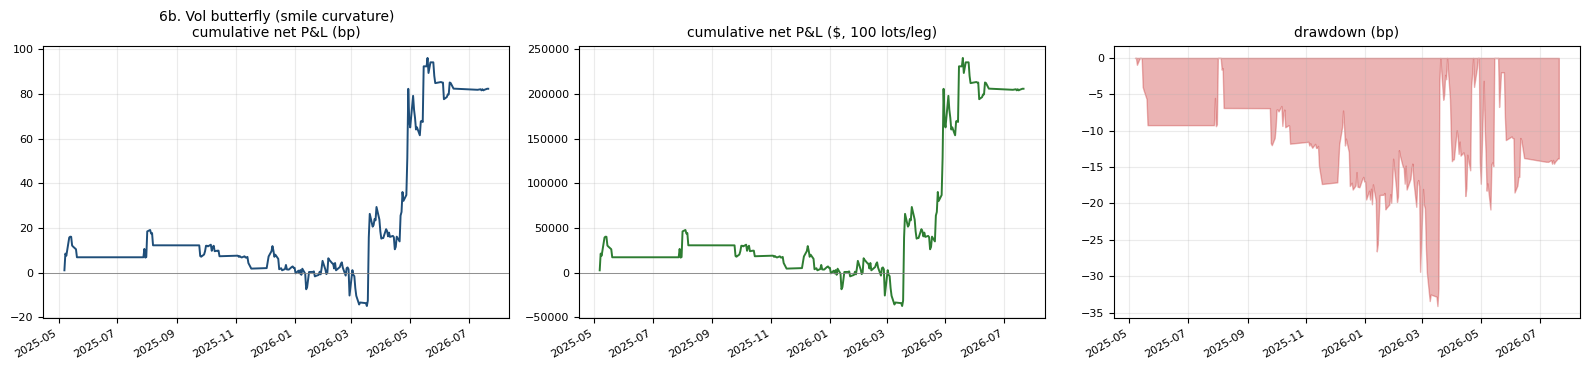


TRADE LOG (first rows)
   key  dir     structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp   net_bp   net_usd  stale_frac  pkg_contracts exit_reason
SFRZ26    1 volfly SFRZ26  2025-05-05 2025-05-06 2025-05-20    10  2.455    9.3449      2.5   6.8449  17112.37       0.265            4.0        time
SFRH27    1 volfly SFRH27  2025-07-23 2025-07-24 2025-08-07    10  2.301    7.8645      2.5   5.3645  13411.21       0.325            4.0        time
SFRZ26   -1 volfly SFRZ26  2025-09-22 2025-09-23 2025-10-07    10 -2.918   -0.0085      2.5  -2.5085  -6271.29       0.344            4.0        time
SFRH27    1 volfly SFRH27  2025-09-30 2025-10-01 2025-10-15    10  2.106    0.1037      2.5  -2.3963  -5990.68       0.336            4.0        time
SFRH27    1 volfly SFRH27  2025-10-30 2025-10-31 2025-11-14    10  2.468   -0.0221      2.5  -2.5221  -6305.19       0.303            4.0        time
SFRM27    1 volfly SFRM27  2025-10-31 2025-11-03 2025-11-17    10  2.473   -

exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0        26     0.538       1.872        48.673      121683.25   0.757    -42.740         15.385
half        26     0.615       2.199        57.183      142958.00   0.893    -32.315         13.692
  t5        45     0.400      -0.212        -9.539      -23847.75  -0.198    -64.874          5.000
 t10        34     0.529       2.423        82.378      205945.50   1.346    -34.095         10.000
 t20        24     0.625       1.544        37.052       92629.75   0.512    -37.383         19.750

MARKS x LAG
signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        34         128.221        43.221   0.781     0.500
       listed    1        34         167.378        82.378   1.346     0.529
same-bar (lag 0) gross inflation: -30.5%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_


6b. Vol butterfly (smile curvature) — median config (not selected)  |  fade|ma5|w60|z2.0|t10|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 4 contracts -> position = 400 contracts across all legs
  trades    36   skipped    0   hit 17%   avg -4.048bp   avg hold 10.0d   stale 36.4%
  total    -145.72bp   $    -364,305   gross -55.72bp
  daily-MTM Sharpe -2.47   maxDD -144.72bp ($-361,805)   worst trade -18.27bp
  t(trade) -3.46   NW t(daily) -2.49   non-overlap SR -1.09   DSR p=0.000 over 108 trials

  LEAGUE ROW  6b. Vol butterfly (smile curvature) / best-config: SELECTION-ARTIFACT  (taker +82.38bp, maker +167.38bp, DSR p=0.005)

  LEAGUE ROW  6b. Vol butterfly (smile curvature) / median-config: DEAD  (taker -145.72bp, maker -55.72bp, DSR p=0.000)


In [5]:
V = vs.rename(columns={"symbol": "key"}).copy()
V["gate"] = True
V = add_event_distance(V)
sig_flyiv = V[["key", "as_of", "gate", "days_to_fomc", "fly_iv_bp",
               "forward_rate"]].copy()
sig_flyiv["signal"] = sig_flyiv["fly_iv_bp"]

# strikes: re-derive from the forward exactly as vol_smile_panel did
from RVUtils.SFRRVLab import pick_listed_strike
QDAY = {k: v for k, v in quotes.groupby(["as_of", "symbol"], sort=False)}


def _smile_strikes(key, date):
    g = QDAY.get((pd.Timestamp(date), key))
    if g is None:
        return None
    f = fwd.get((pd.Timestamp(date), key))
    if f is None or not np.isfinite(f):
        return None
    atm_c = pick_listed_strike(g, "C", f, tol=CONFIG["strike_tol"])
    atm_p = pick_listed_strike(g, "P", f, tol=CONFIG["strike_tol"])
    hk = pick_listed_strike(g, "P", f + CONFIG["wing_offset"],
                            tol=CONFIG["strike_tol"])
    ct = pick_listed_strike(g, "C", f - CONFIG["wing_offset"],
                            tol=CONFIG["strike_tol"])
    if any(x is None for x in (atm_c, atm_p, hk, ct)):
        return None
    return (float(atm_c["strike_price"]), float(atm_p["strike_price"]),
            float(hk["strike_price"]), float(ct["strike_price"]))


def builder_vol_fly(key, exec_date, direction):
    ks = _smile_strikes(key, exec_date)
    if ks is None:
        return None
    kc, kp, khk, kct = ks
    return Structure((
        Leg("option", key, 1.0, "P", khk), Leg("option", key, 1.0, "C", kct),
        Leg("option", key, -1.0, "C", kc), Leg("option", key, -1.0, "P", kp),
    ), label=f"volfly {key}")


out_volfly = run_framework(
    "6b. Vol butterfly (smile curvature)", signals=sig_flyiv, book=lab["book"],
    builder=builder_vol_fly, base=BASE, grid_spec=GRID, params=PARAMS, cls="A",
    note="strangle vs straddle, delta-hedged daily")

## 6c — skew term structure (risk reversal in vol space, across expiries)

skew term-structure rows: 1791


  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 6c. Skew term structure (vol space) — grid ===
  108 configs | median -169.43bp | IQR [-245.43, -108.93] | 0% net-positive | best -42.93bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum  10            120               2.0         z0        21     0.000      -2.044       -42.928     -107318.75  -2.476    -43.101
 momentum  10             60               2.0         z0        27     0.074      -2.248       -60.699     -151747.25  -1.872    -60.872
 momentum   5            120               2.0         z0        26     0.038      -2.363       -61.434     -153584.50  -2.993    -61.864
     fade  10            120               2.0         z0        21     0.000      -2.956       -62.072     -155181.25  -3.369    -63.097
     fade   5            120               2.0         z0        26     0.038      -2.637       

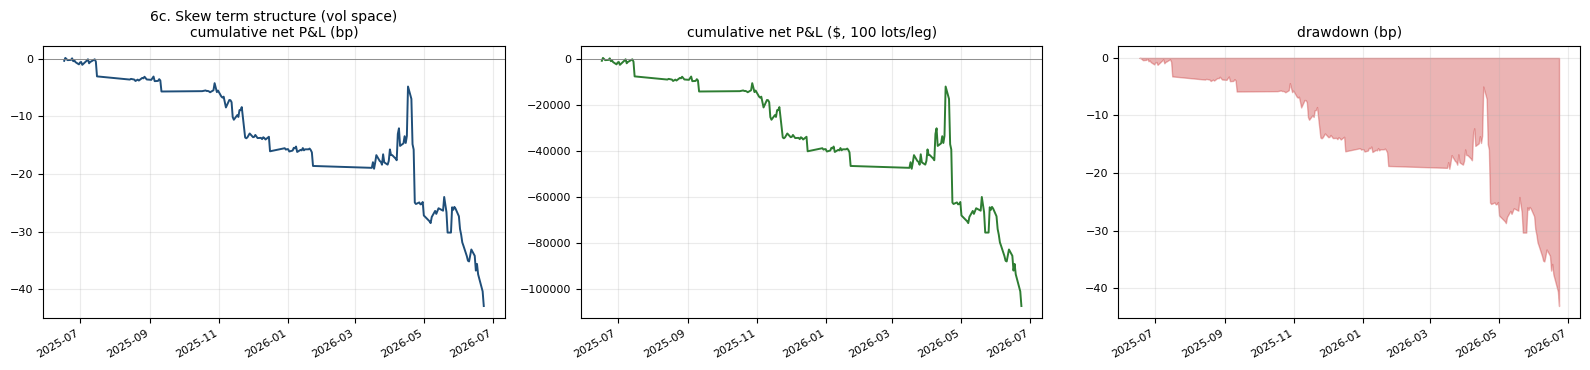


TRADE LOG (first rows)
          key  dir            structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp  net_bp  net_usd  stale_frac  pkg_contracts    exit_reason
SFRZ26-SFRH27    1 skewTS SFRZ26-SFRH27  2025-06-13 2025-06-16 2025-07-16    20  2.162   -0.5316      2.5 -3.0316 -7578.93       0.234            4.0       max_hold
SFRZ26-SFRH27    1 skewTS SFRZ26-SFRH27  2025-08-12 2025-08-13 2025-09-11    20  2.191   -0.1257      2.5 -2.6257 -6564.30       0.204            4.0       max_hold
SFRZ26-SFRH27    1 skewTS SFRZ26-SFRH27  2025-10-15 2025-10-16 2025-11-13    20  2.089   -0.5119      2.5 -3.0119 -7529.72       0.322            4.0       max_hold
SFRH27-SFRM27    1 skewTS SFRH27-SFRM27  2025-10-24 2025-10-27 2025-11-24    20  2.099   -0.0518      2.5 -2.5518 -6379.56       0.257            4.0       max_hold
SFRZ26-SFRM27    1 skewTS SFRZ26-SFRM27  2025-10-24 2025-10-27 2025-11-24    20  2.114   -0.6195      2.5 -3.1195 -7798.72       0.262            4.0  

exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0        21      0.00      -2.044       -42.928     -107318.75  -2.476    -43.101         19.143
half        21      0.00      -2.047       -42.986     -107466.00  -2.560    -43.160         18.571
  t5        46      0.00      -2.411      -110.900     -277251.00  -7.278   -111.074          5.000
 t10        33      0.03      -2.196       -72.484     -181209.75  -4.257    -72.657         10.000
 t20        21      0.00      -2.081       -43.710     -109274.25  -2.369    -43.883         20.000

MARKS x LAG
signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        21           4.539       -47.961  -2.870     0.048
       listed    1        21           9.572       -42.928  -2.476     0.000
same-bar (lag 0) gross inflation: -110.9%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total


6c. Skew term structure (vol space) — median config (not selected)  |  fade|ma10|w120|z1.5|t10|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 4 contracts -> position = 400 contracts across all legs
  trades    61   skipped    0   hit 0%   avg -2.780bp   avg hold 10.0d   stale 22.9%
  total    -169.58bp   $    -423,939   gross -17.08bp
  daily-MTM Sharpe -3.50   maxDD -169.37bp ($-423,424)   worst trade -12.93bp
  t(trade) -13.41   NW t(daily) -3.91   non-overlap SR -4.90   DSR p=0.000 over 108 trials

  LEAGUE ROW  6c. Skew term structure (vol space) / best-config: MARGINAL-maker-only  (taker -42.93bp, maker +9.57bp, DSR p=0.000)

  LEAGUE ROW  6c. Skew term structure (vol space) / median-config: DEAD  (taker -169.58bp, maker -17.08bp, DSR p=0.000)


In [6]:
vidx = V.set_index(["as_of", "key"])["rr_iv_bp"].sort_index()
rows = []
for front, back in contract_pairs(SYMS, gaps=(1, 2)):
    try:
        f = vidx.xs(front, level="key")
        b = vidx.xs(back, level="key")
    except KeyError:
        continue
    j = pd.concat([f.rename("f"), b.rename("b")], axis=1).dropna()
    if j.empty:
        continue
    rows.append(pd.DataFrame({
        "as_of": j.index, "key": f"{front}-{back}", "front": front, "back": back,
        "signal": (j["b"] - j["f"]).to_numpy(), "gate": True}))
skew_ts = (pd.concat(rows, ignore_index=True) if rows else pd.DataFrame())
if len(skew_ts):
    skew_ts = add_event_distance(skew_ts)
print(f"skew term-structure rows: {len(skew_ts)}")


def builder_skew_ts(key, exec_date, direction):
    """Back-expiry risk reversal against the front's, delta-hedged daily."""
    front, back = key.split("-")
    kf = _smile_strikes(front, exec_date)
    kb = _smile_strikes(back, exec_date)
    if kf is None or kb is None:
        return None
    return Structure((
        Leg("option", back, 1.0, "P", kb[2]), Leg("option", back, -1.0, "C", kb[3]),
        Leg("option", front, -1.0, "P", kf[2]), Leg("option", front, 1.0, "C", kf[3]),
    ), label=f"skewTS {key}")


if len(skew_ts):
    out_skew = run_framework(
        "6c. Skew term structure (vol space)", signals=skew_ts, book=lab["book"],
        builder=builder_skew_ts, base=BASE, grid_spec=GRID, params=PARAMS,
        cls="A/B", note="RR(back) - RR(front) in listed normal vol, hedged daily")